# Phase 0: Sanity Check — 기본 채널 추정 동작 검증

**목표**: ReEsNet 기반 채널 추정이 우리 Sionna RT 데이터에서 논문 수준으로 동작하는지 확인

## 검증 항목
1. 데이터 로드 및 형상 확인
2. 단일 BS에서 PlainEstimator (ReEsNet) 학습
3. SNR별 NMSE 곡선
4. LS / LMMSE baseline 대비 성능

## 성공 기준
- NMSE < **-15 dB** @ SNR=20 dB (ReEsNet 논문 참고)
- DNN > LMMSE > LS 순서가 유지되어야 함

In [ ]:
import sys, os
from pathlib import Path

# Add project root to path so 'src' package is importable
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.config import SceneConfig, DatasetConfig
from src.dataset_operation.dataset import ChannelEstimationDataset
from src.dataset_operation.utils import nmse, nmse_db, complex_to_real, add_awgn
from src.models.baselines import PlainEstimator, LMMSEEstimator, LSEstimator
from src.training.trainer import train_local, evaluate, evaluate_per_snr, save_checkpoint, load_checkpoint

device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

## 0-1. 데이터 확인

In [2]:
DATA_DIR = Path(f"{PROJECT_ROOT}/assets/data/channels").resolve()

# Load metadata
meta = pd.read_parquet(DATA_DIR / 'metadata.parquet')
print(f'Total samples: {len(meta)}')
print(f'Snapshots: {meta.snapshot_id.nunique()}')
print(f'UEs per snapshot: ~{len(meta) // meta.snapshot_id.nunique()}')
print(f'\nSamples per BS:')
print(meta.groupby('bs_id').size())

# Check channel shapes
snap0 = np.load(f'{DATA_DIR}/snapshot_0000/channels.npz')
print(f'\nCFR shape: {snap0["cfr"].shape}')  # (N_UE, n_rx_ant, n_tx_ant, n_sc)
print(f'CIR a shape: {snap0["cir_a"].shape}')
print(f'CIR tau shape: {snap0["cir_tau"].shape}')

Total samples: 10000
Snapshots: 100
UEs per snapshot: ~100

Samples per BS:
bs_id
0    1276
1    1421
2    1241
3    1152
4    1102
5    1347
6    1162
7    1299
dtype: int64

CFR shape: (100, 2, 4, 1024)
CIR a shape: (100, 2, 4, 68)
CIR tau shape: (100, 2, 4, 68)


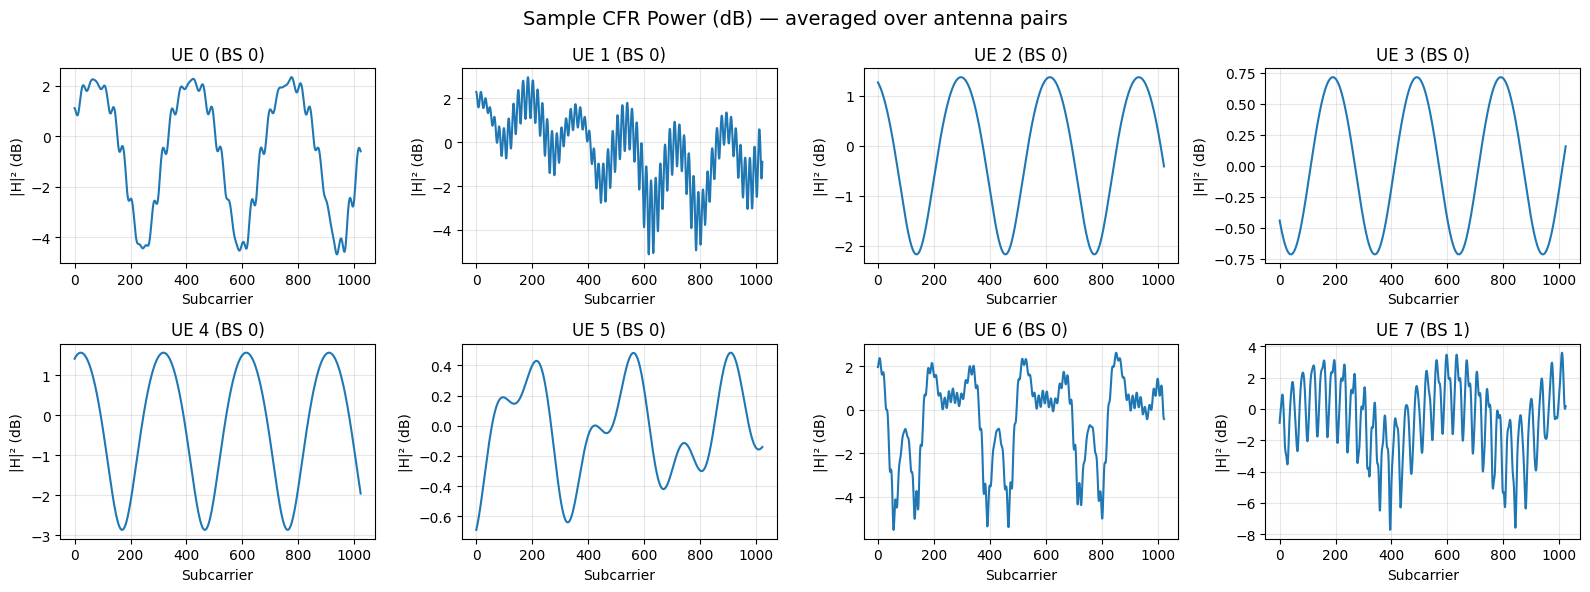

In [3]:
# Visualize sample channels (average over antenna pairs to avoid pol-mismatch zeros)
cfr = snap0['cfr']  # (N_UE, n_rx, n_tx, n_sc) complex

# Skip NaN UEs for visualization
valid_ues = [i for i in range(cfr.shape[0]) if not np.any(np.isnan(cfr[i]))]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for plot_idx in range(min(8, len(valid_ues))):
    i = valid_ues[plot_idx]
    ax = axes[plot_idx // 4, plot_idx % 4]
    # Average power across all rx/tx antenna pairs
    h_power = np.mean(np.abs(cfr[i]) ** 2, axis=(0, 1))  # (n_sc,)
    ax.plot(10 * np.log10(h_power + 1e-10))
    ax.set_title(f'UE {i} (BS {meta.iloc[i]["bs_id"]})')
    ax.set_xlabel('Subcarrier')
    ax.set_ylabel('|H|² (dB)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Sample CFR Power (dB) — averaged over antenna pairs', fontsize=14)
plt.tight_layout()
plt.show()

## 0-2. 단일 BS 채널 추정 결과 (체크포인트 로드)

학습은 `phase0_train.py`로 수행. 여기서는 결과만 로드하여 검증.

In [4]:
bs_counts = meta.groupby('bs_id').size()
target_bs = int(bs_counts.idxmax())
BATCH_SIZE = 256

# Load checkpoint trained at fixed SNR=20
model = PlainEstimator(encoder_channels=64, encoder_blocks=3).to(device)
ckpt_meta = load_checkpoint(model, f'phase0/reesnet_bs{target_bs}_snr20', device=device)
print(ckpt_meta)
print(f'BS{target_bs}: best NMSE = {ckpt_meta["best_val_db"]:.2f} dB (epoch {ckpt_meta["best_epoch"]})')
print(f'Target: < -15 dB')
print(f'Result: {"PASS" if ckpt_meta["best_val_db"] < -15 else "FAIL"}')

  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs1_snr20.pt
{'best_epoch': 77, 'best_val': 0.00729680061340332, 'best_val_db': -21.368675231933594, 'epochs_run': 80, 'train_losses': [2.1434106034922684, 0.6860979218775615, 0.5215541543943357, 0.2867951137064166, 0.2521166608867232, 0.16461698146072967, 0.12738459759025367, 0.12280408774472316, 0.09432791896998237, 0.07992811035701083, 0.08303850235599043, 0.05831837551903639, 0.05176079825965506, 0.046870662874478296, 0.038844582083423215, 0.03625427464877225, 0.043074002697902465, 0.035668611001989904, 0.033116878612161976, 0.030115036993196724, 0.027076766486632695, 0.02449524880047309, 0.024169613738352642, 0.027116257414921095, 0.03220333920838816, 0.02468938138403187, 0.027346906369881508, 0.0231637963588057, 0.020609069736640805, 0.021644088234550687, 0.01710827234083457, 0.020037763600745356, 0.023079940981974672, 0.016213798892116073, 0.016256634045109852, 0.015553003257738984, 0.014858879323793

In [ ]:
# Training curve from saved losses
if 'train_losses' in ckpt_meta and 'val_losses' in ckpt_meta:
    train_losses = ckpt_meta['train_losses']
    val_losses = ckpt_meta['val_losses']

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(10*np.log10(train_losses), label='Train', alpha=0.7)
    ax.plot(10*np.log10(val_losses), label='Val', linewidth=2)
    ax.axhline(y=-15, color='r', linestyle='--', label='Target: -15 dB')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NMSE (dB)')
    ax.set_title(f'ReEsNet Training on BS{target_bs} @ SNR=20 dB')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('train_losses/val_losses not in checkpoint meta.')
    print('Re-run: python -m src.experiments.phase0_train --all')
    print(f'Available keys: {list(ckpt_meta.keys())}')

## 0-3. SNR별 NMSE 곡선 + Baseline 비교

In [6]:
# Load mixed-SNR model (= independent model trained on SNR 0-30)
model_mixed = PlainEstimator(encoder_channels=64, encoder_blocks=3).to(device)
load_checkpoint(model_mixed, f'phase0/reesnet_bs{target_bs}_independent', device=device)

# Load LMMSE model
lmmse = LMMSEEstimator(n_ant_pairs=8, n_subcarriers=1024).to(device)
load_checkpoint(lmmse, f'phase0/lmmse_bs{target_bs}', device=device)

  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs1_independent.pt
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/lmmse_bs1.pt


{'best_epoch': 27,
 'best_val': 0.25785425305366516,
 'best_val_db': -5.886257290840149,
 'epochs_run': 50,
 'train_losses': [0.2860271024790051,
  0.28822092416054074,
  0.28224228134224133,
  0.2848567359068764,
  0.28689959860450526,
  0.28176120838103313,
  0.28270059490462074,
  0.28038036425191143,
  0.28363281821946373,
  0.2774171423610797,
  0.27900527584423657,
  0.2811532295998253,
  0.2776013527751399,
  0.27584698957656695,
  0.2759326734052238,
  0.27347436246028445,
  0.2781682111295982,
  0.27277982052052496,
  0.2736128326572666,
  0.2736953642178959,
  0.269120984021507,
  0.2729385544677073,
  0.2680406817890677,
  0.27063948217281797,
  0.2683546377433336,
  0.26901337407556253,
  0.2689388499793593,
  0.26648347558527646,
  0.26431223513417296,
  0.2690656505767189,
  0.2660574498804898,
  0.26526038924279194,
  0.26693343449155343,
  0.2665746695082971,
  0.26709945031882193,
  0.2696465548625492,
  0.2685048325182298,
  0.26188127013320095,
  0.26538111145745974,

In [7]:
# Evaluate at specific SNR values
SNR_LIST = [0, 5, 10, 15, 20, 25, 30]

results_per_snr = {}
for name, mdl in [('ReEsNet', model_mixed), ('LMMSE', lmmse)]:
    results_per_snr[name] = evaluate_per_snr(
        mdl, ChannelEstimationDataset, DATA_DIR, [target_bs],
        SNR_LIST, batch_size=64, device=device,
    )

# LS baseline (identity — just returns noisy input)
ls_results = {}
for snr in SNR_LIST:
    ds_snr = ChannelEstimationDataset(data_dir=DATA_DIR, bs_ids=[target_bs], fixed_snr_db=snr)
    loader = DataLoader(ds_snr, batch_size=64)
    total = 0
    n = 0
    for batch in loader:
        x = batch['input']
        y = batch['target']
        total += nmse(x, y).item() * x.size(0)  # LS = just return input
        n += x.size(0)
    ls_results[snr] = 10 * torch.log10(torch.tensor(total / n)).item()
results_per_snr['LS'] = ls_results

print('\nSNR (dB) | LS (dB) | LMMSE (dB) | ReEsNet (dB)')
print('-' * 50)
for snr in SNR_LIST:
    print(f'  {snr:5.0f}   | {results_per_snr["LS"][snr]:7.2f} | '
          f'{results_per_snr["LMMSE"][snr]:10.2f} | {results_per_snr["ReEsNet"][snr]:11.2f}')

  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples
  Filtered 37/1421 NaN samples

SNR (dB) | LS (dB) | LMMSE (dB) | ReEsNet (dB)
--------------------------------------------------
      0   |   -0.00 |      -3.00 |       -8.17
      5   |   -5.00 |      -5.02 |      -12.67
     10   |  -10.00 |      -5.92 |      -16.71
     15   |  -15.00 |      -6.25 |      -19.94
     20   |  -20.00 |      -6.35 |      -21.98
     25   |  -2

In [ ]:
# Plot: SNR vs NMSE
fig, ax = plt.subplots(figsize=(8, 5))
markers = {'LS': 's', 'LMMSE': '^', 'ReEsNet': 'o'}
colors = {'LS': 'gray', 'LMMSE': 'C1', 'ReEsNet': 'C0'}

for name in ['LS', 'LMMSE', 'ReEsNet']:
    vals = [results_per_snr[name][s] for s in SNR_LIST]
    ax.plot(SNR_LIST, vals, marker=markers[name], label=name,
            color=colors[name], linewidth=2, markersize=8)

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('NMSE (dB)', fontsize=12)
ax.set_title(f'Channel Estimation Performance — BS{target_bs}', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Validation
reesnet_20 = results_per_snr['ReEsNet'][20]
print(f'\n=== Phase 0 결과 ===')
print(f'ReEsNet @ SNR=20 dB: {reesnet_20:.2f} dB')
print(f'LS > LMMSE > ReEsNet 순서: {results_per_snr["LS"][20] > results_per_snr["LMMSE"][20] > reesnet_20}')
print(f'NMSE < -15 dB: {reesnet_20 < -15}')
print(f'\n전체 판정: {"PASS ✓ → Phase 1 진행" if reesnet_20 < -15 else "FAIL ✗ → 원인 분석 필요"}')

## 0-4. 다중 BS 독립 학습

In [9]:
# Load per-BS independent checkpoints and evaluate at SNR=20 dB
EVAL_SNR = 20.0
all_bs = sorted(meta.bs_id.unique())
bs_results = {}

for bs_id in all_bs:
    ckpt_name = f'phase0/reesnet_bs{bs_id}_independent'
    try:
        m = PlainEstimator(encoder_channels=64, encoder_blocks=3).to(device)
        meta_ckpt = load_checkpoint(m, ckpt_name, device=device)
    except FileNotFoundError:
        print(f'BS{bs_id}: checkpoint not found, skipping')
        continue

    snr20_result = evaluate_per_snr(
        m, ChannelEstimationDataset, DATA_DIR, [bs_id],
        [EVAL_SNR], batch_size=64, device=device,
    )
    bs_results[bs_id] = snr20_result[EVAL_SNR]

print('\n=== 다중 BS 결과 (SNR=20 dB) ===')
all_pass = True
for bs, db in sorted(bs_results.items()):
    status = 'PASS' if db < -10 else 'FAIL'
    if db >= -10:
        all_pass = False
    print(f'  BS{bs}: {db:.2f} dB [{status}]')
print(f'\nPhase 0 통과: {"PASS" if all_pass else "FAIL"} (기준: 모든 BS에서 NMSE < -10 dB @ SNR=20 dB)')

  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs0_independent.pt
  Filtered 3/1276 NaN samples
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs1_independent.pt
  Filtered 37/1421 NaN samples
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs2_independent.pt
  Filtered 121/1241 NaN samples
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs3_independent.pt
  Filtered 7/1152 NaN samples
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs4_independent.pt
  Filtered 2/1102 NaN samples
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs5_independent.pt
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs6_independent.pt
  Loaded: /home/sungmin/Projects/6g-collaborative_bs/checkpoints/phase0/reesnet_bs7_independent.pt

=== 다중 BS 결과 (SNR=20 dB) ===
  BS0: -23.63 dB [PASS]
 

## Phase 0 최종 판정

### Step 0-2: 단일 BS 채널 추정
- ReEsNet @ SNR=20: **-21.37 dB** (기준: < -15 dB) → **PASS**
- LS < LMMSE < ReEsNet 성능 순서 확인 (저~중SNR 구간)

### Step 0-3: 다중 BS 독립 학습
- 8개 BS 모두 NMSE < -10 dB @ SNR=20 → **PASS**
- BS간 성능 차이 ~4 dB (BS0 best, BS7 worst) — 위치/채널 환경 차이 반영

### Phase 0 통과 → Phase 1 진행 가능

In [ ]:
# Per-BS full SNR-NMSE curves (all 8 BS)
fig, ax = plt.subplots(figsize=(10, 6))

for bs_id in all_bs:
    ckpt_name = f'phase0/reesnet_bs{bs_id}_independent'
    m = PlainEstimator(encoder_channels=64, encoder_blocks=3).to(device)
    load_checkpoint(m, ckpt_name, device=device)
    
    snr_results = evaluate_per_snr(
        m, ChannelEstimationDataset, DATA_DIR, [bs_id],
        SNR_LIST, batch_size=64, device=device,
    )
    vals = [snr_results[s] for s in SNR_LIST]
    style = '-' if bs_id <= 5 else '--'
    ax.plot(SNR_LIST, vals, marker='o', linestyle=style, label=f'BS{bs_id}', linewidth=2)

# LS reference
ls_ref = [results_per_snr['LS'][s] for s in SNR_LIST]
ax.plot(SNR_LIST, ls_ref, 'k--', marker='s', alpha=0.5, label='LS (ref)', linewidth=1)

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('NMSE (dB)', fontsize=12)
ax.set_title('All BS Independent ReEsNet — SNR vs NMSE', fontsize=13)
ax.legend(fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Bar chart: per-BS NMSE @ SNR=20 dB
fig, ax = plt.subplots(figsize=(10, 5))
bs_ids = sorted(bs_results.keys())
nmse_vals = [bs_results[b] for b in bs_ids]
colors = ['C0' if b <= 5 else 'C3' for b in bs_ids]  # blue=pretrain, red=test

bars = ax.bar([f'BS{b}' for b in bs_ids], nmse_vals, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(y=-10, color='red', linestyle='--', linewidth=1.5, label='Pass threshold: -10 dB')
ax.axhline(y=-15, color='orange', linestyle='--', linewidth=1.5, label='Target: -15 dB')

# Add value labels
for bar, val in zip(bars, nmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val - 0.8, f'{val:.1f}',
            ha='center', va='top', fontsize=10, fontweight='bold', color='white')

ax.set_ylabel('NMSE (dB)', fontsize=12)
ax.set_title('Per-BS Independent Training — NMSE @ SNR=20 dB', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Legend for pretrain/test split
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='C0', edgecolor='black', label='Pre-train BS (0-5)'),
    Patch(facecolor='C3', edgecolor='black', label='Test BS (6-7)'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Pass: -10 dB'),
    plt.Line2D([0], [0], color='orange', linestyle='--', label='Target: -15 dB'),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nMean NMSE: {np.mean(nmse_vals):.2f} dB')
print(f'Std NMSE:  {np.std(nmse_vals):.2f} dB')
print(f'Best:  BS{bs_ids[np.argmin(nmse_vals)]} ({min(nmse_vals):.2f} dB)')
print(f'Worst: BS{bs_ids[np.argmax(nmse_vals)]} ({max(nmse_vals):.2f} dB)')